In [ ]:
import pandas as pd

## Load the dataset

I'll load the `movies.csv` file into a pandas DataFrame and display the first 5 rows to get a quick overview of the data.

In [ ]:
try:
    df = pd.read_csv('/content/movies.csv')
    print('Dataset loaded successfully!')
    display(df.head())
except FileNotFoundError:
    print("Error: 'movies.csv' not found. Please make sure the file is uploaded to '/content/movies.csv' or update the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully!


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Correlation between Genre, Consumption (Gross), and Score

Let's analyze the average 'gross' and 'score' for each genre to identify trends in popularity and critical reception.

In [ ]:
genre_analysis = df.groupby('genre').agg(
    average_score=('score', 'mean'),
    total_gross=('gross', 'sum')
).reset_index()

print('Top 10 Genres by Average Score:')
display(genre_analysis.sort_values(by='average_score', ascending=False).head(10))

print('\nTop 10 Genres by Total Gross Revenue:')
display(genre_analysis.sort_values(by='total_gross', ascending=False).head(10))

Top 10 Genres by Average Score:


,genre,average_score,total_gross
9,History,8.300000,0.000000e+00
12,Musical,8.050000,5.190692e+06
11,Music,7.200000,1.100140e+05
3,Biography,7.030926,2.072958e+10
2,Animation,6.769231,8.014205e+10
6,Drama,6.693668,5.715065e+10
5,Crime,6.671506,2.135545e+10
13,Mystery,6.665000,2.023671e+09
14,Romance,6.410000,1.883950e+08
7,Family,6.363636,2.157897e+09



Top 10 Genres by Total Gross Revenue:


,genre,average_score,total_gross
0,Action,6.202817,2.434359e+11
4,Comedy,6.193987,9.717547e+10
2,Animation,6.769231,8.014205e+10
6,Drama,6.693668,5.715065e+10
1,Adventure,6.291569,4.591660e+10
5,Crime,6.671506,2.135545e+10
3,Biography,7.030926,2.072958e+10
10,Horror,5.750621,1.454333e+10
7,Family,6.363636,2.157897e+09
13,Mystery,6.665000,2.023671e+09


## Top 15 Genres by Consumption (Total Gross) and their Budgets

Let's visualize the relationship between total gross revenue and total budget for the 15 most consumed genres to understand profitability and investment patterns.

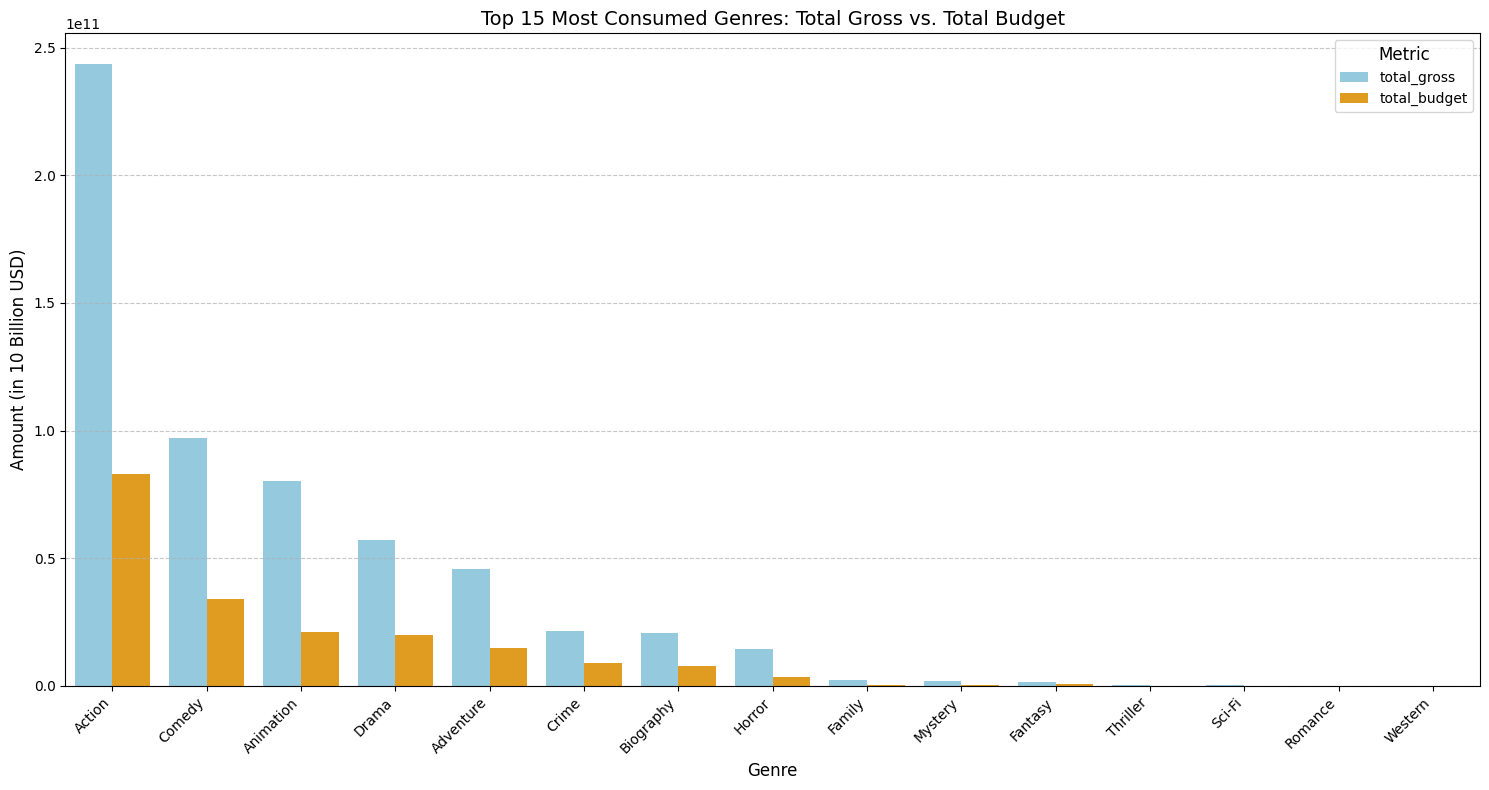

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate total gross and total budget by genre
genre_consumption_budget = df.groupby('genre').agg(
    total_gross=('gross', 'sum'),
    total_budget=('budget', 'sum')
).reset_index()

# Get the top 15 most consumed genres (by total_gross)
top_15_consumed_genres = genre_consumption_budget.sort_values(by='total_gross', ascending=False).head(15)

plt.figure(figsize=(15, 8))

# Create a grouped bar chart for Total Gross and Total Budget
# Melt the DataFrame to long format for easier plotting with seaborn
melted_data = top_15_consumed_genres.melt(id_vars=['genre'], value_vars=['total_gross', 'total_budget'],
                                          var_name='Metric', value_name='Amount')

sns.barplot(x='genre', y='Amount', hue='Metric', data=melted_data, palette={'total_gross': 'skyblue', 'total_budget': 'orange'})

plt.xlabel('Genre', fontsize=12)
plt.ylabel('Amount (in 10 Billion USD)', fontsize=12)
plt.title('Top 15 Most Consumed Genres: Total Gross vs. Total Budget', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Metric', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()